In [23]:
import ipywidgets
import numpy as np
import matplotlib.pyplot as plt

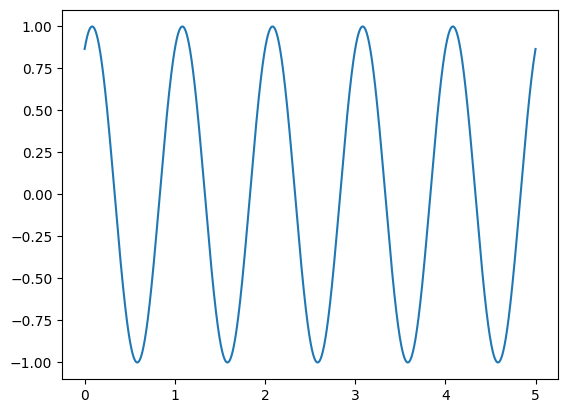

In [24]:
FS = 1000  # Hz
T = 5  # s
t = np.linspace(0, T, T*FS)


def plot_harmonic(phase_shift: float):
    signal = np.cos(2 * np.pi * t - phase_shift)
    plt.plot(t, signal)


# phase_shift_slider = ipywidgets.widgets.FloatSlider(min=0, max=2 * np.pi, step=0.01, value=np.pi / 6)
# ipywidgets.interact(plot_harmonic, phase_shift=phase_shift_slider)
plot_harmonic(phase_shift=np.pi / 6)

In [25]:
def dct_vec(fs: float, N: int, k: int):
    t = np.linspace(0, N / fs, N)
    return np.cos(2 * np.pi * fs / N * k * t)


def dst_vec(fs: float, N: int, k: int):
    t = np.linspace(0, N / fs, N)
    return np.sin(2 * np.pi * fs / N * k * t)


def pin_to_hz(pin_idx: int, fs: float, N: int):
    return (fs * pin_idx) / N

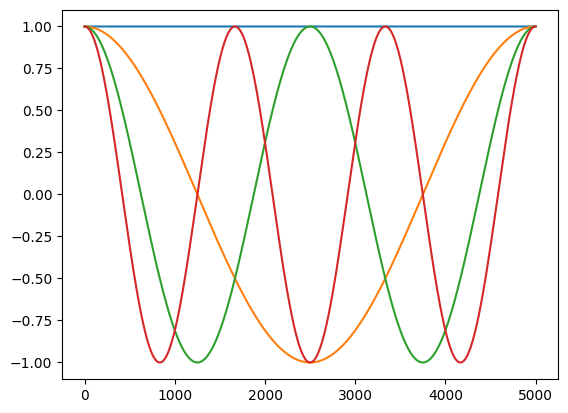

In [26]:
def plot_dct_vecs(max_k: int):
    for k in range(max_k+1):
        dct_k = dct_vec(fs=FS, N=FS*T, k=k)
        plt.plot(dct_k)

# max_k_slider = ipywidgets.widgets.IntSlider(min=0, max=10, step=1, value=3)
# ipywidgets.interact(plot_dct_vecs, max_k=max_k_slider)
plot_dct_vecs(max_k=3)

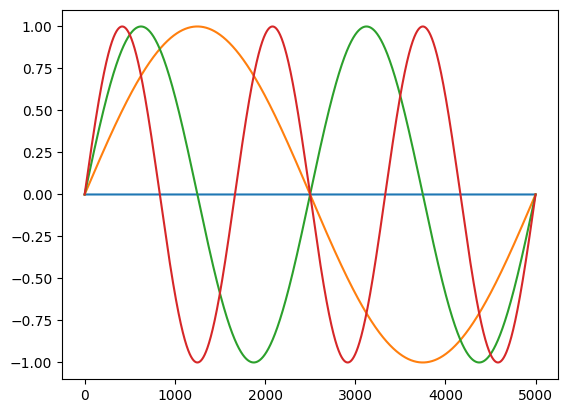

In [27]:
def plot_dst_vecs(max_k: int):
    for k in range(max_k+1):
        dst_k = dst_vec(fs=FS, N=FS*T, k=k)
        plt.plot(dst_k)

# max_k_slider = ipywidgets.widgets.IntSlider(min=0, max=10, step=1, value=3)
# ipywidgets.interact(plot_dst_vecs, max_k=max_k_slider)
plot_dst_vecs(max_k=3)

In [28]:
DCT_Matrix = np.zeros((FS * T, FS * T))
for k in range(FS * T):
    DCT_Matrix[k] = dct_vec(fs=FS, N=FS * T, k=k)

DST_Matrix = np.zeros((FS * T, FS * T))
for k in range(FS * T):
    DST_Matrix[k] = dst_vec(fs=FS, N=FS * T, k=k)

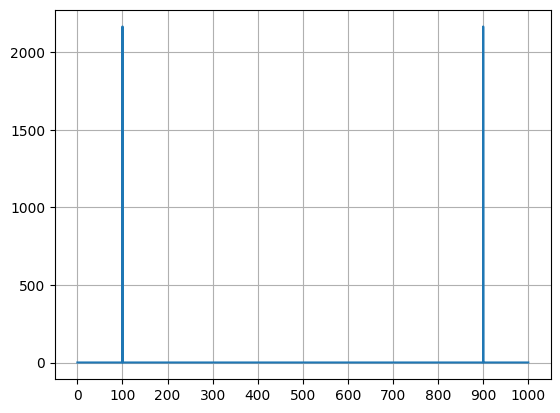

In [29]:
hz_axis = np.array([pin_to_hz(pin_idx=p, fs=FS, N=T * FS) for p in range(0, T * FS)])


def plot_dct_transform(f: int):
    signal = np.cos(2 * np.pi * f * t - np.pi / 6)
    DCT_Transform = np.matmul(DCT_Matrix, signal)
    plt.grid()
    plt.xticks(np.arange(0, 1001, 100))
    plt.plot(hz_axis, DCT_Transform)


# f_slider = ipywidgets.widgets.IntSlider(min=0, max=FS / 2, step=1, value=100)
# ipywidgets.interact(plot_dct_transform, f=f_slider)
plot_dct_transform(f=100)

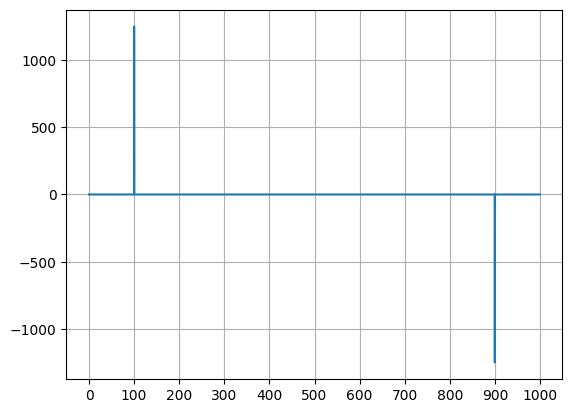

In [30]:
def plot_dst_transform(f: int):
    signal = np.cos(2 * np.pi * f * t - np.pi / 6)
    DST_Transform = np.matmul(DST_Matrix, signal)
    plt.grid()
    plt.xticks(np.arange(0, 1001, 100))
    plt.plot(hz_axis, DST_Transform)

# f_slider = ipywidgets.widgets.IntSlider(min=0, max=FS/2, step=1, value=100)
# ipywidgets.interact(plot_dst_transform, f=f_slider)
plot_dst_transform(f=100)

In [31]:
signal = np.cos(2 * np.pi * 100 * t - np.pi / 6)
DCT_Transform = np.matmul(DCT_Matrix, signal)
DST_Transform = np.matmul(DST_Matrix, signal)

Re = max(DCT_Transform) / (FS * T)
Im = max(DST_Transform) / (FS * T)

p1 = [Re, Im]
p2 = [Re, -Im]

In [32]:
Amp = 2 * np.sqrt(np.square(Re) + np.square(Im))
Phase = np.rad2deg(np.arctan(Im / Re))

print('Amp:', Amp)
print('Phase:', Phase)

Amp: 1.0001000149985002
Phase: 29.99007707227087
